In [1]:
import kwant
import numpy as np
import scipy.sparse.linalg as sla
import matplotlib.pyplot as plt

In [2]:
a = 1

In [25]:
# The translation invariant directions, will be the directions in which wraparound will make the system infinite
# Create a system which will be tr. inv. in x and y
syst = kwant.Builder(kwant.TranslationalSymmetry((a, 0, 0),(0, a, 0)) )

In [26]:
def build_sys(syst,W,L,H,t_x = 1.0,t_y = 2.0,t_z = 4.0):

    lat = kwant.lattice.cubic(a,norbs=1)

    # Define the scattering region

    syst[(lat(x, y, z) for x in range(L) for y in range(W) for z in range(H))] = 0#2*(t_x+t_y+t_z)

    syst[lat.neighbors()[0]] = -t_x
    syst[lat.neighbors()[1]] = -t_y
    syst[lat.neighbors()[2]] = -t_z
    
    return syst

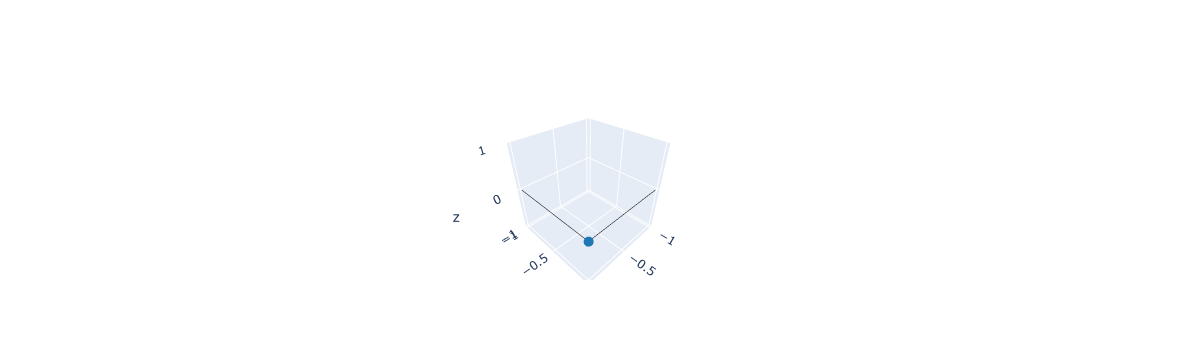

In [27]:
syst = build_sys(syst,W=4,L=4,H=1)

kwant.plotter.set_engine("plotly")
kwant.plot(syst);

In [28]:
systf = kwant.wraparound.wraparound(syst).finalized()

## Evaluate dispersion in x

In [33]:
ks = np.linspace(-np.pi,np.pi,50)
Es_x = []
# Here k_x and k_y are correspond to the first and second translation invariant direction, NOT necessarily x and y
for k in ks:
    k = dict(k_x=k,k_y=0)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_x.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )

## Evaluate dispersion in y

In [34]:
Es_y = []
for k in ks:
    k = dict(k_x=0,k_y=k)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_y.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )

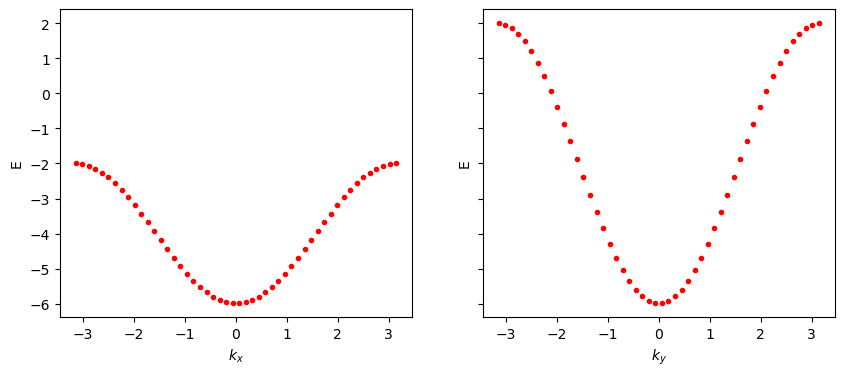

In [35]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharey = True)
ax[0].plot(ks,Es_x,'r.',lw=0);
ax[1].plot(ks,Es_y,'r.',lw=0);
ax[0].set_xlabel('$k_x$'); ax[0].set_ylabel('E');
ax[1].set_xlabel('$k_y$'); ax[1].set_ylabel('E');

## Increase the unit cell size in x

In [22]:
# In this case we can include more lattice sites in the direction (x) that we also want to have tranlsation invariance in

syst = kwant.Builder(kwant.TranslationalSymmetry((4*a, 0, 0),(0, a, 0)) )

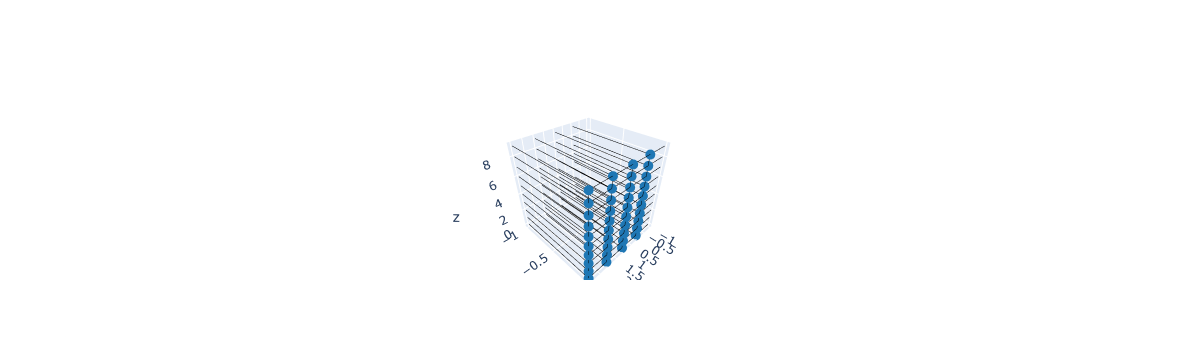

In [23]:
syst = build_sys(syst,W=10,L=10,H=10)

kwant.plotter.set_engine("plotly")
kwant.plot(syst);

In [12]:
systf = kwant.wraparound.wraparound(syst).finalized()

In [13]:
ks = np.linspace(-np.pi,np.pi,100)
Es_x = []
for k in ks:
    k = dict(k_x=k,k_y=0)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_x.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )
    

In [14]:
Es_y = []
for k in ks:
    k = dict(k_x=0,k_y=k)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_y.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )

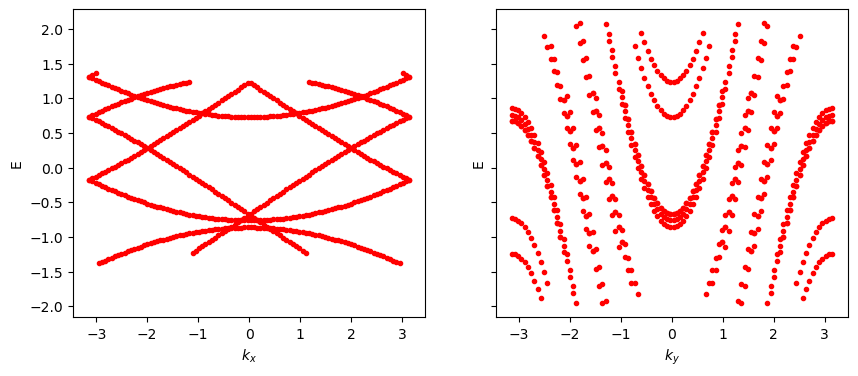

In [15]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharey = True)
ax[0].plot(ks,Es_x,'r.',lw=0);
ax[1].plot(ks,Es_y,'r.',lw=0);
ax[0].set_xlabel('$k_x$'); ax[0].set_ylabel('E');
ax[1].set_xlabel('$k_y$'); ax[1].set_ylabel('E');

# Hamiltonian_submatrix only cares about the total number of k's, not the tr. inv. directions

In [16]:
# Create a system which is tr. inv. in z and y
syst = kwant.Builder(kwant.TranslationalSymmetry((0, a, 0),(0, 0, a)) )

In [17]:
syst = build_sys(syst,W=10,L=10,H=10)

kwant.plotter.set_engine("plotly")
kwant.plot(syst);

In [18]:
systf = kwant.wraparound.wraparound(syst).finalized()

In [19]:
ks = np.linspace(-np.pi,np.pi,100)
Es_x = []
for k in ks:
    k = dict(k_x=k,k_y=0)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_x.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )

In [20]:
Es_y = []
for k in ks:
    k = dict(k_x=0,k_y=k)
    
    h_k = systf.hamiltonian_submatrix(params=k)
    Es_y.append( sla.eigs(h_k, sigma = 0, return_eigenvectors=False).real )

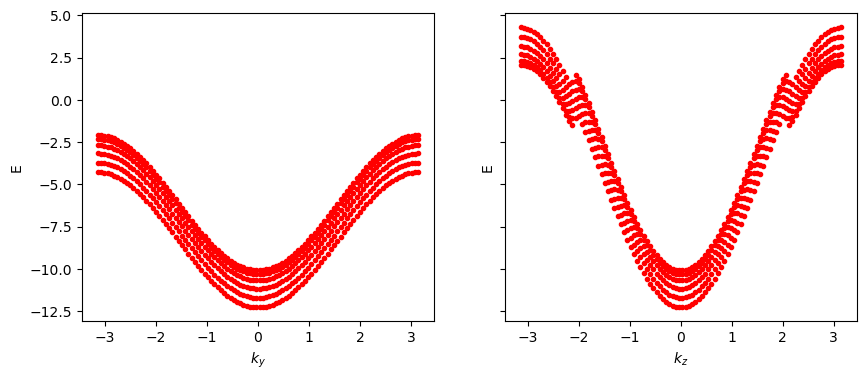

In [21]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharey = True)
ax[0].plot(ks,Es_x,'r.',lw=0);
ax[1].plot(ks,Es_y,'r.',lw=0);
ax[0].set_xlabel('$k_y$'); ax[0].set_ylabel('E');
ax[1].set_xlabel('$k_z$'); ax[1].set_ylabel('E');